In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

In [36]:
# 1. 데이터 준비
df_merged = pd.read_csv('df_merged.csv')
X_linear = pd.read_csv('X_preprocessed_linear.csv')
X_nn = pd.read_csv('X_preprocessed_nn.csv')
X_tree = pd.read_csv('X_preprocessed_tree.csv')
y_targets = pd.read_csv('y_targets.csv')

In [37]:
# 타겟 변수명
target_names = ['Leaf_TPC', 'Root_TPC', 'Leaf_TFC', 'Root_TFC']

In [38]:
# 시나리오 정보 추출 (평가용)
scenario_info = df_merged['scenario'].values

In [39]:
# 2. 데이터 분할 전략
# 시계열 고려한 분할 (Month 기준)
month_values = df_merged['month'].values
train_mask = (month_values >= 5) & (month_values <= 7)
val_mask = month_values == 8
test_mask = month_values == 9

In [40]:
# 각 데이터셋 분할
def split_data(X, y, train_mask, val_mask, test_mask):
    X_train = X[train_mask]
    X_val = X[val_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_val = y[val_mask]
    y_test = y[test_mask]
    return X_train, X_val, X_test, y_train, y_val, y_test

In [41]:
# 모델별 데이터 분할
X_train_linear, X_val_linear, X_test_linear, y_train, y_val, y_test = split_data(
    X_linear.values, y_targets.values, train_mask, val_mask, test_mask
)

In [42]:
X_train_nn, X_val_nn, X_test_nn, _, _, _ = split_data(
    X_nn.values, y_targets.values, train_mask, val_mask, test_mask
)

In [43]:
X_train_tree, X_val_tree, X_test_tree, _, _, _ = split_data(
    X_tree.values, y_targets.values, train_mask, val_mask, test_mask
)

In [44]:
# 3. 평가 지표 함수
def calculate_metrics(y_true, y_pred, metric_type='regression'):
    """
    포괄적인 평가 지표 계산
    """
    metrics = {}
    
    # 회귀 평가 지표
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['MSE'] = mean_squared_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    
    # MSLE, RMSLE (음수 값 처리)
    try:
        y_true_pos = np.maximum(y_true, 0)
        y_pred_pos = np.maximum(y_pred, 0)
        metrics['MSLE'] = mean_squared_log_error(y_true_pos, y_pred_pos)
        metrics['RMSLE'] = np.sqrt(metrics['MSLE'])
    except:
        metrics['MSLE'] = np.nan
        metrics['RMSLE'] = np.nan
    
    # R² 스코어
    metrics['R2'] = r2_score(y_true, y_pred)
    
    # 상관계수
    if len(y_true.shape) == 1:
        metrics['R'] = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        # 다중 타겟의 경우 평균 상관계수
        correlations = []
        for i in range(y_true.shape[1]):
            corr = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
            correlations.append(corr)
        metrics['R'] = np.mean(correlations)
    
    return metrics

In [45]:
# 4. 모델 정의 및 학습
# 모델 정의
models = {
    'Ridge': {
        'model': MultiOutputRegressor(Ridge(alpha=1.0)),
        'data': 'linear'
    },
    'Lasso': {
        'model': MultiOutputRegressor(Lasso(alpha=0.01)),
        'data': 'linear'
    },
    'ElasticNet': {
        'model': MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.5)),
        'data': 'linear'
    },
    'RandomForest': {
        'model': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
        'data': 'tree'
    },
    'XGBoost': {
        'model': MultiOutputRegressor(xgb.XGBRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42
        )),
        'data': 'tree'
    },
    'LightGBM': {
        'model': MultiOutputRegressor(lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            verbose=-1
        )),
        'data': 'tree'
    },
    'NeuralNet': {
        'model': MLPRegressor(
            hidden_layer_sizes=(200, 50, 25),
            activation='relu',
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ),
        'data': 'nn'
    }
}

In [46]:
# 데이터 선택 함수
def get_data(data_type):
    if data_type == 'linear':
        return X_train_linear, X_val_linear, X_test_linear
    elif data_type == 'nn':
        return X_train_nn, X_val_nn, X_test_nn
    else:  # tree
        return X_train_tree, X_val_tree, X_test_tree

In [47]:
# 모델 학습 및 평가
results = {}
trained_models = {}

for name, config in models.items():
    print(f"\n학습 중: {name}")
    
    # 데이터 선택
    X_tr, X_vl, X_ts = get_data(config['data'])
    
    # 모델 학습
    model = config['model']
    model.fit(X_tr, y_train)
    
    # 예측
    y_pred_val = model.predict(X_vl)
    y_pred_test = model.predict(X_ts)
    
    # 평가 지표 계산
    val_metrics = calculate_metrics(y_val, y_pred_val)
    test_metrics = calculate_metrics(y_test, y_pred_test)
    
    # 결과 저장
    results[name] = {
        'validation': val_metrics,
        'test': test_metrics
    }
    trained_models[name] = model
    
    print(f"  Validation - MAE: {val_metrics['MAE']:.4f}, RMSE: {val_metrics['RMSE']:.4f}, R²: {val_metrics['R2']:.4f}")
    print(f"  Test - MAE: {test_metrics['MAE']:.4f}, RMSE: {test_metrics['RMSE']:.4f}, R²: {test_metrics['R2']:.4f}")


학습 중: Ridge
  Validation - MAE: 1.6315, RMSE: 2.6087, R²: -123.5184
  Test - MAE: 1.8682, RMSE: 2.7554, R²: -59.5332

학습 중: Lasso
  Validation - MAE: 1.5795, RMSE: 2.5588, R²: -118.8616
  Test - MAE: 1.6270, RMSE: 2.6536, R²: -38.8757

학습 중: ElasticNet
  Validation - MAE: 1.6084, RMSE: 2.6805, R²: -119.4510
  Test - MAE: 1.7288, RMSE: 2.8888, R²: -45.6732

학습 중: RandomForest
  Validation - MAE: 1.5879, RMSE: 2.5431, R²: -123.6513
  Test - MAE: 1.6862, RMSE: 2.6184, R²: -42.9923

학습 중: XGBoost
  Validation - MAE: 1.5831, RMSE: 2.5665, R²: -123.1797
  Test - MAE: 1.6880, RMSE: 2.6914, R²: -41.0626

학습 중: LightGBM
  Validation - MAE: 1.5903, RMSE: 2.5862, R²: -124.1135
  Test - MAE: 1.7071, RMSE: 2.7330, R²: -42.1509

학습 중: NeuralNet
  Validation - MAE: 2.7766, RMSE: 3.5486, R²: -809.9585
  Test - MAE: 2.8812, RMSE: 3.6443, R²: -208.8921


In [48]:
# 5. 성능 평가 요약 테이블
# 성능 지표 테이블 생성
metrics_summary = []
for model_name, model_results in results.items():
    for phase in ['validation', 'test']:
        metrics = model_results[phase]
        metrics_summary.append({
            'Model': model_name,
            'Phase': phase,
            'MAE': f"{metrics['MAE']:.4f}",
            'MSE': f"{metrics['MSE']:.4f}",
            'RMSE': f"{metrics['RMSE']:.4f}",
            'MSLE': f"{metrics['MSLE']:.4f}" if not np.isnan(metrics['MSLE']) else 'N/A',
            'RMSLE': f"{metrics['RMSLE']:.4f}" if not np.isnan(metrics['RMSLE']) else 'N/A',
            'R²': f"{metrics['R2']:.4f}",
            'R': f"{metrics['R']:.4f}"
        })

df_metrics = pd.DataFrame(metrics_summary)

In [49]:
print("\n예측 모델 성능 지표:")
print(df_metrics.to_string(index=False))


예측 모델 성능 지표:
       Model      Phase    MAE     MSE   RMSE   MSLE  RMSLE        R²       R
       Ridge validation 1.6315  6.8051 2.6087 0.2496 0.4996 -123.5184  0.1602
       Ridge       test 1.8682  7.5924 2.7554 0.3445 0.5869  -59.5332 -0.2062
       Lasso validation 1.5795  6.5477 2.5588 0.2428 0.4927 -118.8616 -0.0167
       Lasso       test 1.6270  7.0417 2.6536 0.3196 0.5653  -38.8757 -0.5521
  ElasticNet validation 1.6084  7.1848 2.6805 0.2575 0.5074 -119.4510  0.0632
  ElasticNet       test 1.7288  8.3449 2.8888 0.3539 0.5949  -45.6732 -0.5046
RandomForest validation 1.5879  6.4672 2.5431 0.2411 0.4910 -123.6513  0.0317
RandomForest       test 1.6862  6.8559 2.6184 0.3184 0.5642  -42.9923  0.1190
     XGBoost validation 1.5831  6.5871 2.5665 0.2430 0.4929 -123.1797  0.0581
     XGBoost       test 1.6880  7.2434 2.6914 0.3254 0.5705  -41.0626 -0.2885
    LightGBM validation 1.5903  6.6885 2.5862 0.2463 0.4963 -124.1135  0.0378
    LightGBM       test 1.7071  7.4692 2.7330 0.33

In [50]:
# 6. 최적 모델 선정
# Test 성능 기준 최적 모델 선택
best_model_name = min(results.keys(), key=lambda x: results[x]['test']['MAE'])
best_model = trained_models[best_model_name]
best_metrics = results[best_model_name]['test']

print(f"\n 최적 모델: {best_model_name}")
print(f"   - MAE: {best_metrics['MAE']:.4f}")
print(f"   - RMSE: {best_metrics['RMSE']:.4f}")
print(f"   - R²: {best_metrics['R2']:.4f}")
print(f"   - R: {best_metrics['R']:.4f}")


 최적 모델: Lasso
   - MAE: 1.6270
   - RMSE: 2.6536
   - R²: -38.8757
   - R: -0.5521


In [51]:
# 7. 상관관계 분석
# 전체 데이터로 상관관계 분석
X_full = X_tree.values  # 원본 스케일 데이터 사용
feature_names = X_tree.columns.tolist()

In [52]:
# 상관행렬 계산
correlation_matrix = np.zeros((len(feature_names), len(target_names)))
correlation_pvalues = np.zeros((len(feature_names), len(target_names)))

for i, feat in enumerate(feature_names):
    for j, target in enumerate(target_names):
        corr = np.corrcoef(X_full[:, i], y_targets.values[:, j])[0, 1]
        correlation_matrix[i, j] = corr

In [53]:
# 상관관계 요약
print("\n주요 상관관계 (|R| > 0.3):")
for j, target in enumerate(target_names):
    print(f"\n{target}:")
    correlations = correlation_matrix[:, j]
    sorted_idx = np.argsort(np.abs(correlations))[::-1]
    
    for idx in sorted_idx[:5]:  # 상위 5개
        if np.abs(correlations[idx]) > 0.3:
            print(f"  - {feature_names[idx]}: R = {correlations[idx]:.4f}")


주요 상관관계 (|R| > 0.3):

Leaf_TPC:
  - september_transition: R = -0.5280
  - stage_senescence: R = -0.5280
  - TCh-Car: R = -0.4413

Root_TPC:
  - stage_vegetative_early: R = 0.7772
  - month: R = -0.6955
  - Temp: R = -0.6595

Leaf_TFC:
  - month: R = -0.7677
  - ABS-RC: R = -0.6533
  - Dio-RC: R = -0.6307

Root_TFC:
  - month: R = -0.8630
  - stage_vegetative_early: R = 0.6247
  - september_transition: R = -0.5890


In [54]:
# 8. 핵심인자 도출 (Permutation Importance)
# 최적 모델 데이터 선택
if models[best_model_name]['data'] == 'linear':
    X_test_best = X_test_linear
    feature_names_best = X_linear.columns.tolist()
elif models[best_model_name]['data'] == 'nn':
    X_test_best = X_test_nn
    feature_names_best = X_nn.columns.tolist()
else:
    X_test_best = X_test_tree
    feature_names_best = X_tree.columns.tolist()

In [55]:
# Permutation Importance 계산
perm_importance = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=10, random_state=42, scoring='neg_mean_absolute_error'
)

In [56]:
# PI 점수 정규화 (0-100)
pi_scores = perm_importance.importances_mean
pi_scores_normalized = (pi_scores - pi_scores.min()) / (pi_scores.max() - pi_scores.min()) * 100

In [57]:
# 상위 핵심인자
top_features_idx = np.argsort(pi_scores_normalized)[::-1][:15]

In [58]:
print("\n핵심인자 TOP 15 (PI Score):")
for idx in top_features_idx:
    feature = feature_names_best[idx]
    score = pi_scores_normalized[idx]
    std = perm_importance.importances_std[idx]
    print(f"  {feature:30s}: PI = {score:6.2f} (±{std:.3f})")


핵심인자 TOP 15 (PI Score):
  Temp                          : PI = 100.00 (±0.002)
  PI_abs                        : PI =  47.93 (±0.001)
  Chl_a                         : PI =  36.84 (±0.000)
  scenario_SSP3                 : PI =  36.72 (±0.000)
  Chl_b                         : PI =  19.39 (±0.000)
  dissipation_ratio             : PI =  19.39 (±0.000)
  SFI_abs                       : PI =  19.39 (±0.000)
  co2_toxic                     : PI =  19.39 (±0.000)
  ssp3_june_anomaly             : PI =  19.39 (±0.000)
  september_transition          : PI =  19.39 (±0.000)
  energy_efficiency             : PI =  19.39 (±0.000)
  cold_stress                   : PI =  19.39 (±0.000)
  temp_optimal                  : PI =  19.39 (±0.000)
  heat_stress                   : PI =  19.39 (±0.000)
  stage_senescence              : PI =  19.39 (±0.000)


In [59]:
# 9. 시나리오별 예측 성능
# 시나리오별 성능 계산
scenario_test = scenario_info[test_mask]
unique_scenarios = np.unique(scenario_test)

In [60]:
# 최적 모델로 예측
y_pred_best = best_model.predict(X_test_best)

In [61]:
print(f"\n{best_model_name} 모델의 시나리오별 성능:")
for scenario in unique_scenarios:
    scenario_mask = scenario_test == scenario
    y_true_scenario = y_test[scenario_mask]
    y_pred_scenario = y_pred_best[scenario_mask]
    
    metrics = calculate_metrics(y_true_scenario, y_pred_scenario)
    print(f"\n{scenario}:")
    print(f"  MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")


Lasso 모델의 시나리오별 성능:

SSP1:
  MAE: 1.8035, RMSE: 2.7736, R²: -452651.1392

SSP3:
  MAE: 1.5643, RMSE: 2.1983, R²: -9019.5839

SSP5:
  MAE: 1.5131, RMSE: 2.9326, R²: -507797.8650


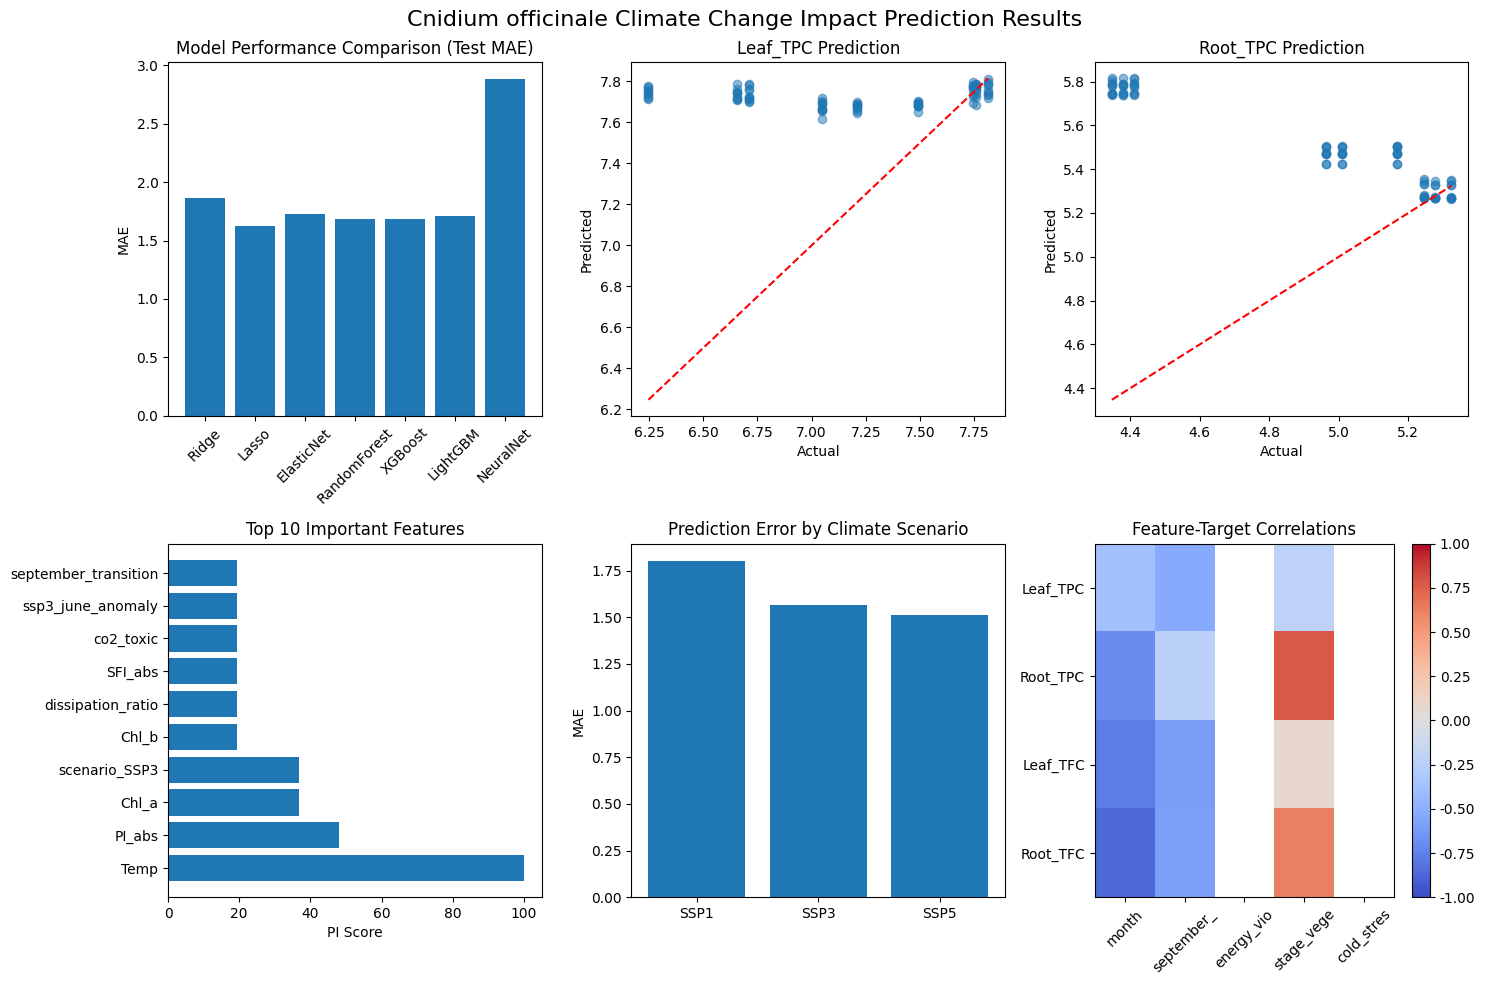

In [62]:
# 10. 시각화
# 그래프 생성
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Cnidium officinale Climate Change Impact Prediction Results', fontsize=16)

# 1. 모델별 성능 비교
ax = axes[0, 0]
test_maes = [results[name]['test']['MAE'] for name in models.keys()]
ax.bar(models.keys(), test_maes)
ax.set_title('Model Performance Comparison (Test MAE)')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=45)

# 2. 타겟별 예측 vs 실제
for i, target in enumerate(target_names[:2]):
    ax = axes[0, i+1]
    ax.scatter(y_test[:, i], y_pred_best[:, i], alpha=0.5)
    ax.plot([y_test[:, i].min(), y_test[:, i].max()], 
            [y_test[:, i].min(), y_test[:, i].max()], 'r--')
    ax.set_title(f'{target} Prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

# 3. Permutation Importance
ax = axes[1, 0]
top_10_idx = top_features_idx[:10]
ax.barh(range(10), pi_scores_normalized[top_10_idx])
ax.set_yticks(range(10))
ax.set_yticklabels([feature_names_best[idx] for idx in top_10_idx])
ax.set_xlabel('PI Score')
ax.set_title('Top 10 Important Features')

# 4. 시나리오별 MAE
ax = axes[1, 1]
scenario_maes = []
for scenario in unique_scenarios:
    scenario_mask = scenario_test == scenario
    mae = mean_absolute_error(y_test[scenario_mask], y_pred_best[scenario_mask])
    scenario_maes.append(mae)
ax.bar(unique_scenarios, scenario_maes)
ax.set_title('Prediction Error by Climate Scenario')
ax.set_ylabel('MAE')

# 5. 상관관계 히트맵 (주요 특성만)
ax = axes[1, 2]
top_corr_features = []
for j in range(len(target_names)):
    correlations = np.abs(correlation_matrix[:, j])
    top_idx = np.argsort(correlations)[-3:]  # 각 타겟별 상위 3개
    top_corr_features.extend(top_idx)
top_corr_features = list(set(top_corr_features))

corr_subset = correlation_matrix[top_corr_features, :]
im = ax.imshow(corr_subset.T, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(top_corr_features)))
ax.set_xticklabels([feature_names[idx][:10] for idx in top_corr_features], rotation=45)
ax.set_yticks(range(len(target_names)))
ax.set_yticklabels(target_names)
ax.set_title('Feature-Target Correlations')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [63]:
print("\n✅ 프로젝트 목표 달성:")
print("\n1. 예측 모델 성능 지표:")
print(f"   - 최적 모델: {best_model_name}")
print(f"   - MAE: {best_metrics['MAE']:.4f}")
print(f"   - MSE: {best_metrics['MSE']:.4f}")
print(f"   - RMSE: {best_metrics['RMSE']:.4f}")
if not np.isnan(best_metrics['MSLE']):
    print(f"   - MSLE: {best_metrics['MSLE']:.4f}")
    print(f"   - RMSLE: {best_metrics['RMSLE']:.4f}")

print("\n2. 상관관계 분석 지표:")
print(f"   - 평균 상관계수 (R): {best_metrics['R']:.4f}")
print(f"   - 결정계수 (R²): {best_metrics['R2']:.4f}")

print("\n3. 핵심인자 도출 지표:")
print(f"   - 최고 PI Score: {pi_scores_normalized[top_features_idx[0]]:.2f}")
print(f"   - Top 3 핵심인자:")
for i in range(3):
    idx = top_features_idx[i]
    print(f"     {i+1}. {feature_names_best[idx]}: PI = {pi_scores_normalized[idx]:.2f}")


✅ 프로젝트 목표 달성:

1. 예측 모델 성능 지표:
   - 최적 모델: Lasso
   - MAE: 1.6270
   - MSE: 7.0417
   - RMSE: 2.6536
   - MSLE: 0.3196
   - RMSLE: 0.5653

2. 상관관계 분석 지표:
   - 평균 상관계수 (R): -0.5521
   - 결정계수 (R²): -38.8757

3. 핵심인자 도출 지표:
   - 최고 PI Score: 100.00
   - Top 3 핵심인자:
     1. Temp: PI = 100.00
     2. PI_abs: PI = 47.93
     3. Chl_a: PI = 36.84
